# Does IS Training Reduce the Variance of the Loss Estimate?

**Setup:** Train a GRU posterior estimator for AR(1) parameters $(\rho, \sigma)$. For each proposal concentration $\alpha$, we use a $\text{Beta}(\alpha,\alpha)$ proposal on $\tilde\rho$ and $\text{Beta}(\alpha, \beta_\sigma)$ on $\tilde\sigma$, with IS-weighted loss:

$$L^{IS}(\phi) = \frac{1}{N}\sum_{i=1}^{N} w(\theta^{(i)})\,({\theta^{(i)} - f_\phi(Y^{(i)})})^2, \qquad \theta \sim q_\alpha$$

**Thorough version:**
1. All models trained simultaneously, tracking per-epoch losses
2. Learning curves plotted superimposed
3. More $\alpha$ values for finer resolution
4. Evaluation under both IS-weighted and uniform MC
5. Per-parameter breakdown ($\rho$ vs $\sigma$)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import torch
import torch.nn as nn
from collections import defaultdict

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Configuration
A = 5.0
T = 64
ALPHA_VALUES = [1.0, 0.8, 0.6, 0.5, 0.3]
BETA_SIGMA = 1

# Training
N_EPOCHS = 128
N_BATCHES = 128
BATCH_SIZE = 128
LR = 0.002

# Variance experiment
K = 500   # independent loss estimates per model
N = 128   # samples per estimate

# Colours for each alpha
COLORS = {1.0: '#1f77b4', 0.8: '#ff7f0e', 0.6: '#2ca02c', 0.5: '#d62728', 0.3: '#9467bd'}

In [3]:
def sample_from_proposal(batch_size, alpha_rho, alpha_sigma, beta_sigma, A, device='cpu'):
    rho_tilde = np.random.beta(alpha_rho, alpha_rho, size=batch_size)
    sigma_tilde = np.random.beta(alpha_sigma, beta_sigma, size=batch_size)
    rho = torch.tensor(2 * rho_tilde - 1, dtype=torch.float32, device=device)
    sigma = torch.tensor(A * sigma_tilde, dtype=torch.float32, device=device)
    return rho, sigma

def compute_importance_weights(rho, sigma, alpha_rho, alpha_sigma, beta_sigma, A):
    if torch.is_tensor(rho):
        rho = rho.cpu().numpy()
        sigma = sigma.cpu().numpy()
    rho_tilde = (rho + 1) / 2
    sigma_tilde = sigma / A
    q_rho = stats.beta.pdf(rho_tilde, alpha_rho, alpha_rho) / 2
    q_sigma = stats.beta.pdf(sigma_tilde, alpha_sigma, beta_sigma) / A
    p_theta = 1.0 / (2 * A)
    return p_theta / (q_rho * q_sigma)

def simulate_ar1_batch(rho, sigma, T, batch_size, device='cpu'):
    eps = torch.randn(batch_size, T, device=device) * sigma[:, None]
    rho_safe = torch.clamp(rho, -0.9999, 0.9999)
    x0 = torch.randn(batch_size, device=device) * sigma / torch.sqrt(1 - rho_safe**2 + 1e-8)
    x = torch.zeros(batch_size, T, device=device)
    x[:, 0] = rho * x0 + eps[:, 0]
    for t in range(1, T):
        x[:, t] = rho * x[:, t-1] + eps[:, t]
    return x

class GRUPosteriorEstimator(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, mlp_hidden=128):
        super().__init__()
        self.gru = nn.GRU(input_size=input_dim, hidden_size=hidden_dim,
                          num_layers=num_layers, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, 32), nn.ReLU(),
            nn.Linear(32, 2))
    def forward(self, x):
        x = x.unsqueeze(-1)
        gru_out, _ = self.gru(x)
        pooled = gru_out.mean(dim=1)
        raw = self.mlp(pooled)
        rho = torch.tanh(raw[:, 0])
        sigma = torch.exp(raw[:, 1])
        return torch.stack([rho, sigma], dim=1)

print("Functions loaded!")

Functions loaded!


## Train all models simultaneously, tracking per-epoch losses

We interleave training so all models see the same number of gradient steps at each epoch checkpoint. We record:
- **IS-weighted training loss** (what each model actually optimises)
- **Uniform validation loss** (unweighted MSE on fresh uniform samples) — the true quantity we care about

In [4]:
np.random.seed(42)
torch.manual_seed(42)

# Create all models and optimizers upfront
models = {}
optimizers = {}
for alpha in ALPHA_VALUES:
    m = GRUPosteriorEstimator().to(device)
    models[alpha] = m
    optimizers[alpha] = torch.optim.Adam(m.parameters(), lr=LR)

# Tracking dictionaries
history = {
    'is_train_loss': defaultdict(list),   # IS-weighted training loss per epoch
    'uniform_val_loss': defaultdict(list), # unweighted uniform val loss per epoch
    'uniform_val_rho': defaultdict(list),  # per-parameter val losses
    'uniform_val_sigma': defaultdict(list),
}

VAL_SIZE = 512  # validation batch size

for epoch in range(N_EPOCHS):
    # --- Train one epoch for every alpha ---
    for alpha in ALPHA_VALUES:
        model = models[alpha]
        opt = optimizers[alpha]
        model.train()

        epoch_loss_acc = 0.0
        n_valid_batches = 0

        for _ in range(N_BATCHES):
            rho, sigma = sample_from_proposal(BATCH_SIZE, alpha, alpha, BETA_SIGMA, A, device=device)
            w = compute_importance_weights(rho, sigma, alpha, alpha, BETA_SIGMA, A)
            w = torch.tensor(w, dtype=torch.float32, device=device)

            x = simulate_ar1_batch(rho, sigma, T, BATCH_SIZE, device=device)
            if torch.isnan(x).any():
                continue

            pred = model(x)
            per_sample_loss = ((pred - torch.stack([rho, sigma], dim=1))**2).sum(dim=1)
            loss = (w * per_sample_loss).mean()

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

            epoch_loss_acc += loss.item()
            n_valid_batches += 1

        history['is_train_loss'][alpha].append(epoch_loss_acc / max(n_valid_batches, 1))

    # --- Uniform validation (same batch for all models) ---
    val_rho = torch.empty(VAL_SIZE, device=device).uniform_(-1, 1)
    val_sigma = torch.empty(VAL_SIZE, device=device).uniform_(0, A)
    val_x = simulate_ar1_batch(val_rho, val_sigma, T, VAL_SIZE, device=device)
    val_target = torch.stack([val_rho, val_sigma], dim=1)

    for alpha in ALPHA_VALUES:
        models[alpha].eval()
        with torch.no_grad():
            pred = models[alpha](val_x)
            err = (pred - val_target)**2
            history['uniform_val_loss'][alpha].append(err.sum(dim=1).mean().item())
            history['uniform_val_rho'][alpha].append(err[:, 0].mean().item())
            history['uniform_val_sigma'][alpha].append(err[:, 1].mean().item())

    if (epoch + 1) % 16 == 0:
        msg = f"Epoch {epoch+1}/{N_EPOCHS} | "
        msg += " | ".join([f"a={a}: val={history['uniform_val_loss'][a][-1]:.4f}" for a in ALPHA_VALUES])
        print(msg)

# Set all to eval
for m in models.values():
    m.eval()

print("\nAll models trained!")

Epoch 16/128 | a=1.0: val=0.0792 | a=0.8: val=0.1123 | a=0.6: val=0.0907 | a=0.5: val=0.0865 | a=0.3: val=0.0894
Epoch 32/128 | a=1.0: val=0.0822 | a=0.8: val=0.0899 | a=0.6: val=0.0934 | a=0.5: val=0.0846 | a=0.3: val=0.0880
Epoch 48/128 | a=1.0: val=0.0742 | a=0.8: val=0.0774 | a=0.6: val=0.0806 | a=0.5: val=0.0792 | a=0.3: val=0.0924
Epoch 64/128 | a=1.0: val=0.0900 | a=0.8: val=0.0752 | a=0.6: val=0.0733 | a=0.5: val=0.0789 | a=0.3: val=0.0847
Epoch 80/128 | a=1.0: val=0.0983 | a=0.8: val=0.0827 | a=0.6: val=0.0840 | a=0.5: val=0.0834 | a=0.3: val=0.0888
Epoch 96/128 | a=1.0: val=0.0964 | a=0.8: val=0.0817 | a=0.6: val=0.0841 | a=0.5: val=0.0858 | a=0.3: val=0.0848
Epoch 112/128 | a=1.0: val=0.0783 | a=0.8: val=0.0772 | a=0.6: val=0.0813 | a=0.5: val=0.0761 | a=0.3: val=0.0782
Epoch 128/128 | a=1.0: val=0.0771 | a=0.8: val=0.0810 | a=0.6: val=0.0813 | a=0.5: val=0.0760 | a=0.3: val=0.0853

All models trained!


## Learning Curves (superimposed)

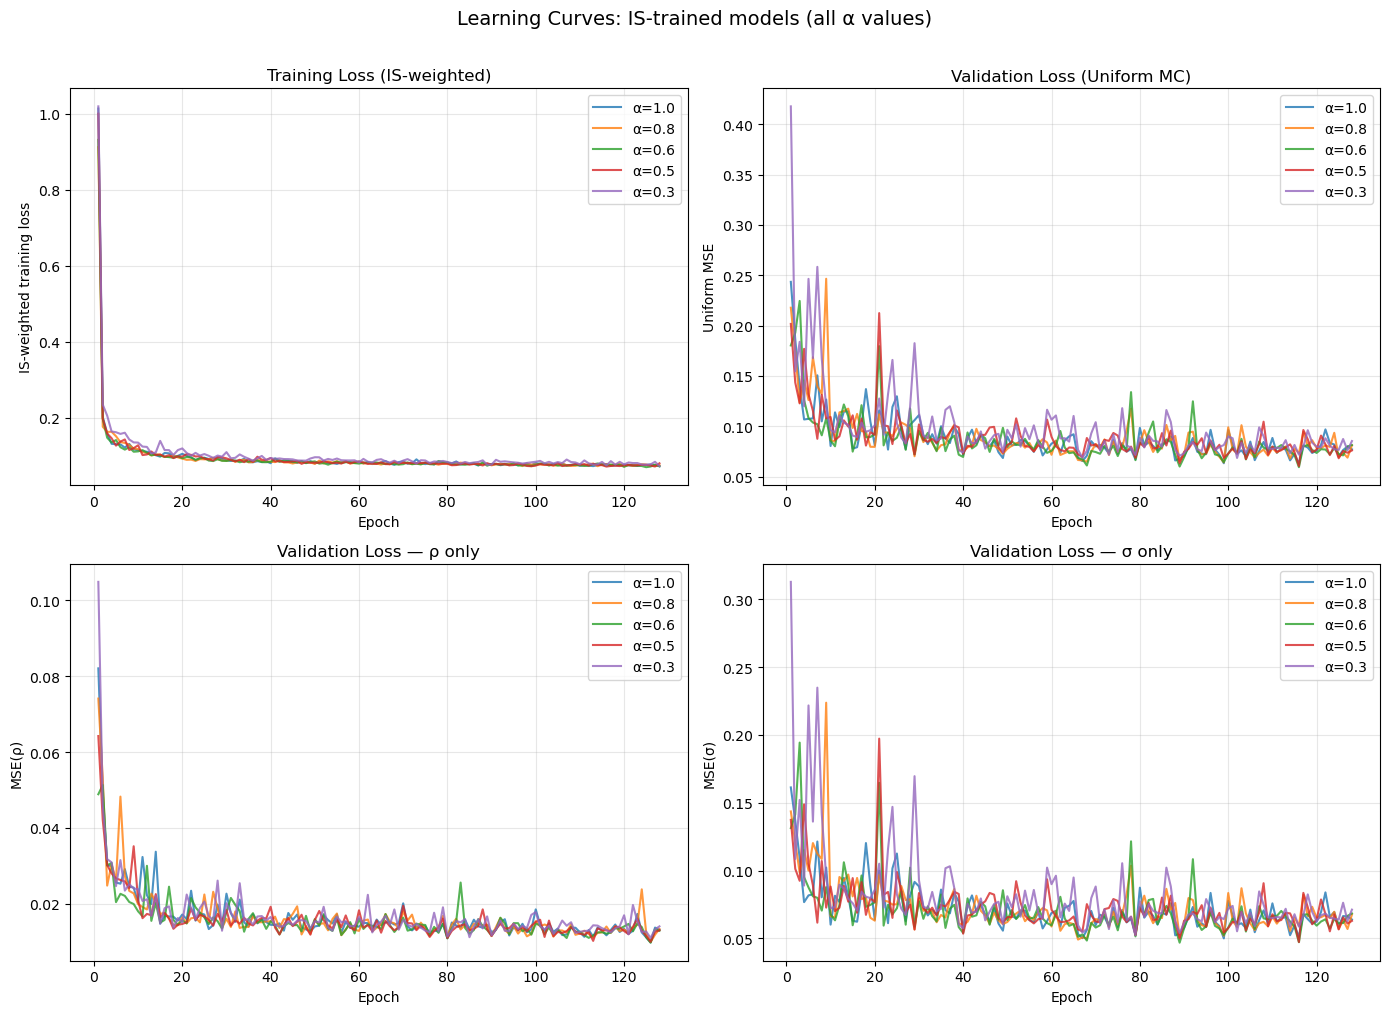

In [5]:
epochs = np.arange(1, N_EPOCHS + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- 1. IS-weighted training loss ---
ax = axes[0, 0]
for alpha in ALPHA_VALUES:
    ax.plot(epochs, history['is_train_loss'][alpha], label=f'α={alpha}', color=COLORS[alpha], alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('IS-weighted training loss')
ax.set_title('Training Loss (IS-weighted)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- 2. Uniform validation loss (total) ---
ax = axes[0, 1]
for alpha in ALPHA_VALUES:
    ax.plot(epochs, history['uniform_val_loss'][alpha], label=f'α={alpha}', color=COLORS[alpha], alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Uniform MSE')
ax.set_title('Validation Loss (Uniform MC)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- 3. Uniform val loss - rho only ---
ax = axes[1, 0]
for alpha in ALPHA_VALUES:
    ax.plot(epochs, history['uniform_val_rho'][alpha], label=f'α={alpha}', color=COLORS[alpha], alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE(ρ)')
ax.set_title('Validation Loss — ρ only')
ax.legend()
ax.grid(True, alpha=0.3)

# --- 4. Uniform val loss - sigma only ---
ax = axes[1, 1]
for alpha in ALPHA_VALUES:
    ax.plot(epochs, history['uniform_val_sigma'][alpha], label=f'α={alpha}', color=COLORS[alpha], alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE(σ)')
ax.set_title('Validation Loss — σ only')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Learning Curves: IS-trained models (all α values)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Variance of the Loss Estimator

Evaluate each model $K$ times:
1. **IS evaluation** — each model sampled from its own proposal, IS-weighted
2. **Uniform MC evaluation** — all models evaluated on the same uniform draws

In [6]:
np.random.seed(0)

# --- 1. IS evaluation (each model uses its own proposal) ---
is_estimates = {}
is_estimates_rho = {}
is_estimates_sigma = {}

for alpha in ALPHA_VALUES:
    model = models[alpha]
    ests, ests_rho, ests_sigma = [], [], []
    for k in range(K):
        rho, sigma = sample_from_proposal(N, alpha, alpha, BETA_SIGMA, A, device=device)
        w = compute_importance_weights(rho, sigma, alpha, alpha, BETA_SIGMA, A)
        w = torch.tensor(w, dtype=torch.float32, device=device)

        x = simulate_ar1_batch(rho, sigma, T, N, device=device)
        with torch.no_grad():
            pred = model(x)
        err = (pred - torch.stack([rho, sigma], dim=1))**2
        ests.append((w * err.sum(dim=1)).mean().item())
        ests_rho.append((w * err[:, 0]).mean().item())
        ests_sigma.append((w * err[:, 1]).mean().item())

    is_estimates[alpha] = np.array(ests)
    is_estimates_rho[alpha] = np.array(ests_rho)
    is_estimates_sigma[alpha] = np.array(ests_sigma)

# --- 2. Uniform MC evaluation ---
mc_estimates = {}
mc_estimates_rho = {}
mc_estimates_sigma = {}

np.random.seed(99)
for alpha in ALPHA_VALUES:
    model = models[alpha]
    ests, ests_rho, ests_sigma = [], [], []
    for k in range(K):
        rho = torch.empty(N, device=device).uniform_(-1, 1)
        sigma = torch.empty(N, device=device).uniform_(0, A)

        x = simulate_ar1_batch(rho, sigma, T, N, device=device)
        with torch.no_grad():
            pred = model(x)
        err = (pred - torch.stack([rho, sigma], dim=1))**2
        ests.append(err.sum(dim=1).mean().item())
        ests_rho.append(err[:, 0].mean().item())
        ests_sigma.append(err[:, 1].mean().item())

    mc_estimates[alpha] = np.array(ests)
    mc_estimates_rho[alpha] = np.array(ests_rho)
    mc_estimates_sigma[alpha] = np.array(ests_sigma)

print("Evaluation done!")

Evaluation done!


## Results Tables

In [7]:
# --- IS evaluation table ---
print("=" * 60)
print("IS EVALUATION (each model uses its own proposal)")
print("=" * 60)
mc_var = is_estimates[1.0].var()
print(f"{'Alpha':<10} {'Mean':<12} {'Std':<12} {'Var Ratio':<12}")
print("-" * 46)
for alpha in ALPHA_VALUES:
    est = is_estimates[alpha]
    ratio = est.var() / mc_var
    print(f"α={alpha:<8} {est.mean():<12.4f} {est.std():<12.4f} {ratio:<12.2f}")

print()

# --- Uniform MC evaluation table ---
print("=" * 60)
print("UNIFORM MC EVALUATION (all models on uniform samples)")
print("=" * 60)
mc_var_u = mc_estimates[1.0].var()
print(f"{'Alpha':<10} {'Mean':<12} {'Std':<12} {'Var Ratio':<12}")
print("-" * 46)
for alpha in ALPHA_VALUES:
    est = mc_estimates[alpha]
    ratio = est.var() / mc_var_u
    print(f"α={alpha:<8} {est.mean():<12.4f} {est.std():<12.4f} {ratio:<12.2f}")

print()

# --- Per-parameter breakdown (uniform MC) ---
print("=" * 60)
print("PER-PARAMETER BREAKDOWN (Uniform MC)")
print("=" * 60)
var_rho_base = mc_estimates_rho[1.0].var()
var_sigma_base = mc_estimates_sigma[1.0].var()
print(f"{'Alpha':<10} {'Mean(ρ)':<12} {'VarRatio(ρ)':<14} {'Mean(σ)':<12} {'VarRatio(σ)':<14}")
print("-" * 62)
for alpha in ALPHA_VALUES:
    mr = mc_estimates_rho[alpha].mean()
    rr = mc_estimates_rho[alpha].var() / var_rho_base
    ms = mc_estimates_sigma[alpha].mean()
    rs = mc_estimates_sigma[alpha].var() / var_sigma_base
    print(f"α={alpha:<8} {mr:<12.4f} {rr:<14.2f} {ms:<12.4f} {rs:<14.2f}")

IS EVALUATION (each model uses its own proposal)
Alpha      Mean         Std          Var Ratio   
----------------------------------------------
α=1.0      0.0728       0.0111       1.00        
α=0.8      0.0754       0.0122       1.21        
α=0.6      0.0729       0.0135       1.48        
α=0.5      0.0724       0.0159       2.07        
α=0.3      0.0814       0.0249       5.04        

UNIFORM MC EVALUATION (all models on uniform samples)
Alpha      Mean         Std          Var Ratio   
----------------------------------------------
α=1.0      0.0742       0.0123       1.00        
α=0.8      0.0746       0.0118       0.93        
α=0.6      0.0721       0.0104       0.72        
α=0.5      0.0720       0.0106       0.75        
α=0.3      0.0795       0.0107       0.76        

PER-PARAMETER BREAKDOWN (Uniform MC)
Alpha      Mean(ρ)      VarRatio(ρ)    Mean(σ)      VarRatio(σ)   
--------------------------------------------------------------
α=1.0      0.0128       1.00      

## Variance Ratio Bar Charts

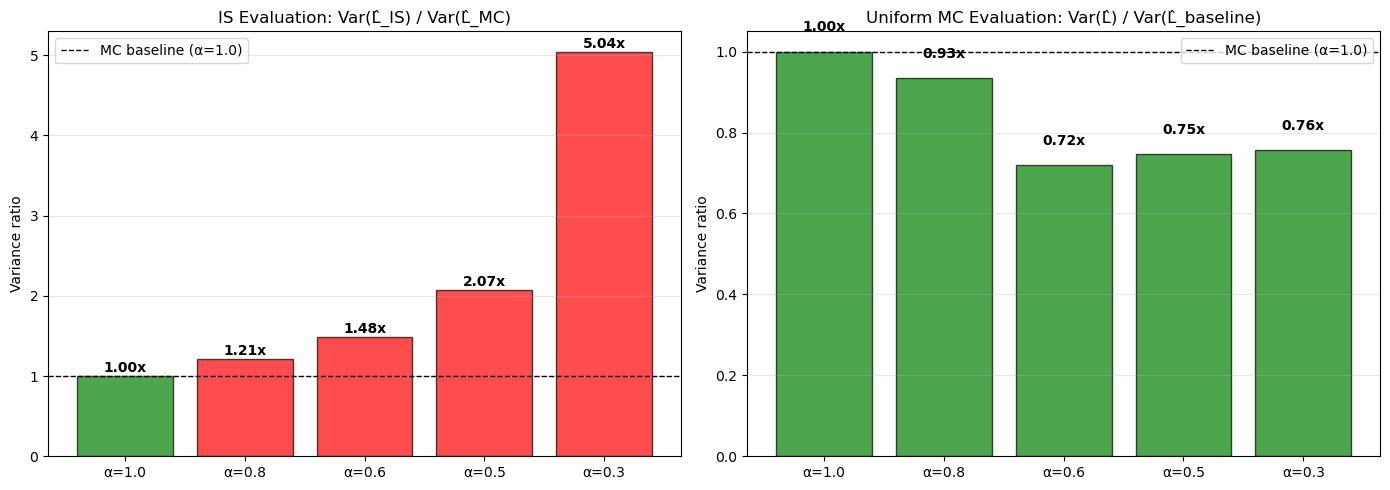

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_pos = np.arange(len(ALPHA_VALUES))
labels = [f'α={a}' for a in ALPHA_VALUES]

# --- IS evaluation variance ratios ---
ax = axes[0]
is_var_base = is_estimates[1.0].var()
is_ratios = [is_estimates[a].var() / is_var_base for a in ALPHA_VALUES]
colors_is = ['green' if r <= 1.0 else 'red' for r in is_ratios]
bars = ax.bar(x_pos, is_ratios, color=colors_is, alpha=0.7, edgecolor='black')
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='MC baseline (α=1.0)')
for bar, r in zip(bars, is_ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{r:.2f}x', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylabel('Variance ratio')
ax.set_title('IS Evaluation: Var(L̂_IS) / Var(L̂_MC)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# --- Uniform MC evaluation variance ratios ---
ax = axes[1]
mc_var_base = mc_estimates[1.0].var()
mc_ratios = [mc_estimates[a].var() / mc_var_base for a in ALPHA_VALUES]
colors_mc = ['green' if r <= 1.0 else 'red' for r in mc_ratios]
bars = ax.bar(x_pos, mc_ratios, color=colors_mc, alpha=0.7, edgecolor='black')
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='MC baseline (α=1.0)')
for bar, r in zip(bars, mc_ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{r:.2f}x', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylabel('Variance ratio')
ax.set_title('Uniform MC Evaluation: Var(L̂) / Var(L̂_baseline)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Distribution of Loss Estimates (histograms)

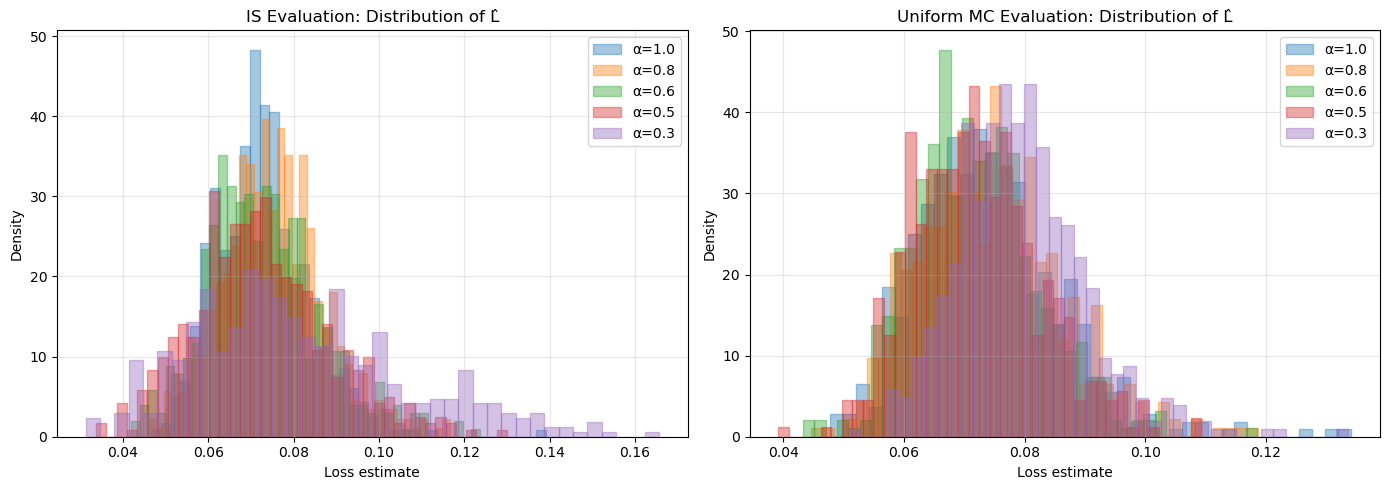

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- IS evaluation histograms ---
ax = axes[0]
for alpha in ALPHA_VALUES:
    ax.hist(is_estimates[alpha], bins=40, alpha=0.4, label=f'α={alpha}',
            color=COLORS[alpha], edgecolor=COLORS[alpha], density=True)
ax.set_xlabel('Loss estimate')
ax.set_ylabel('Density')
ax.set_title('IS Evaluation: Distribution of L̂')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Uniform MC evaluation histograms ---
ax = axes[1]
for alpha in ALPHA_VALUES:
    ax.hist(mc_estimates[alpha], bins=40, alpha=0.4, label=f'α={alpha}',
            color=COLORS[alpha], edgecolor=COLORS[alpha], density=True)
ax.set_xlabel('Loss estimate')
ax.set_ylabel('Density')
ax.set_title('Uniform MC Evaluation: Distribution of L̂')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Effective Sample Size (ESS) of the IS weights

A key diagnostic: $\text{ESS} = \frac{(\sum w_i)^2}{\sum w_i^2}$. Low ESS means the IS weights are dominated by a few large values, inflating variance.

Alpha      Mean ESS       ESS/N (%)      Max w / Mean w  
------------------------------------------------------
α=1.0      10000.0        100.0          1.0             
α=0.8      9336.1         93.4           1.4             
α=0.6      7364.7         73.6           2.3             
α=0.5      6080.2         60.8           3.1             
α=0.3      3106.8         31.1           7.4             


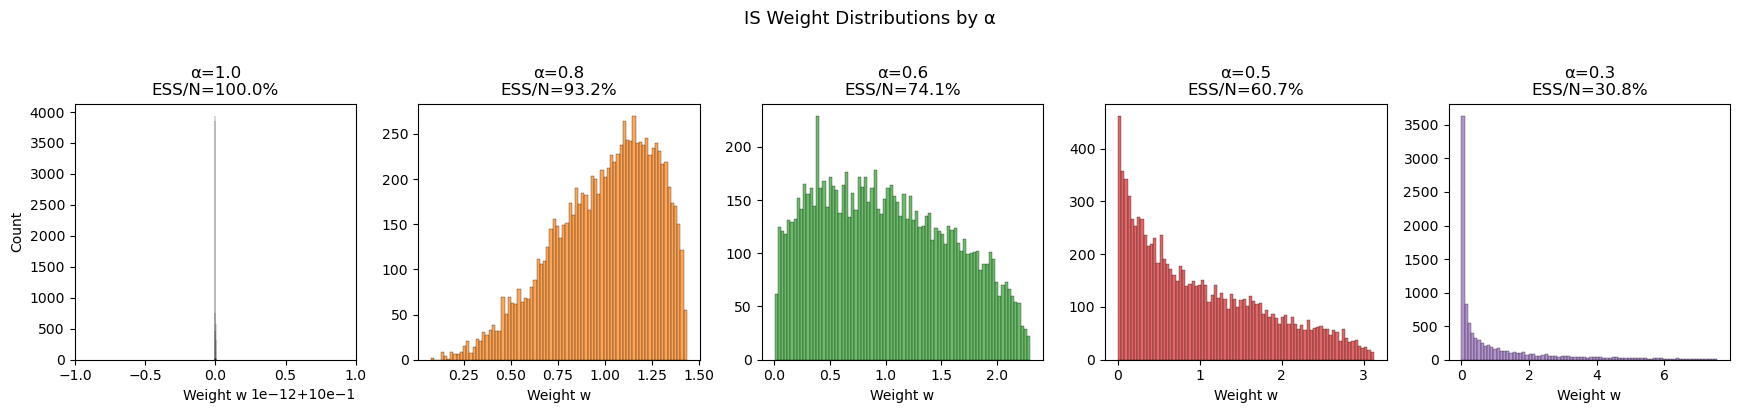

In [10]:
np.random.seed(123)
n_ess_samples = 10000

print(f"{'Alpha':<10} {'Mean ESS':<14} {'ESS/N (%)':<14} {'Max w / Mean w':<16}")
print("-" * 54)
for alpha in ALPHA_VALUES:
    rho, sigma = sample_from_proposal(n_ess_samples, alpha, alpha, BETA_SIGMA, A)
    w = compute_importance_weights(rho.numpy() if torch.is_tensor(rho) else rho,
                                   sigma.numpy() if torch.is_tensor(sigma) else sigma,
                                   alpha, alpha, BETA_SIGMA, A)
    ess = (w.sum())**2 / (w**2).sum()
    print(f"α={alpha:<8} {ess:<14.1f} {100*ess/n_ess_samples:<14.1f} {w.max()/w.mean():<16.1f}")

# Plot weight distributions
fig, axes = plt.subplots(1, len(ALPHA_VALUES), figsize=(3.5*len(ALPHA_VALUES), 4), sharey=False)
for i, alpha in enumerate(ALPHA_VALUES):
    rho, sigma = sample_from_proposal(n_ess_samples, alpha, alpha, BETA_SIGMA, A)
    w = compute_importance_weights(rho.numpy() if torch.is_tensor(rho) else rho,
                                   sigma.numpy() if torch.is_tensor(sigma) else sigma,
                                   alpha, alpha, BETA_SIGMA, A)
    axes[i].hist(w, bins=80, color=COLORS[alpha], alpha=0.7, edgecolor='black', linewidth=0.3)
    axes[i].set_title(f'α={alpha}\nESS/N={100*(w.sum()**2/(w**2).sum())/n_ess_samples:.1f}%')
    axes[i].set_xlabel('Weight w')
    axes[i].set_ylabel('Count' if i == 0 else '')

plt.suptitle('IS Weight Distributions by α', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Smoothed Learning Curves (moving average)

Applying a rolling window to smooth out batch-level noise for clearer comparison.

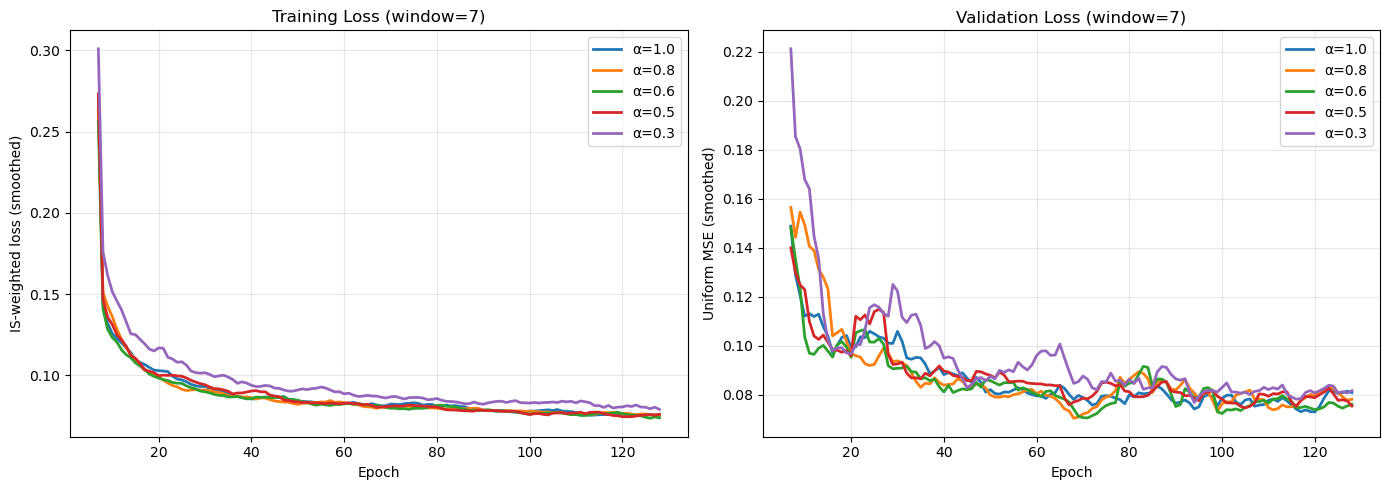

In [11]:
def smooth(y, window=7):
    """Simple moving average."""
    kernel = np.ones(window) / window
    return np.convolve(y, kernel, mode='valid')

epochs_full = np.arange(1, N_EPOCHS + 1)
window = 7

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Smoothed IS training loss
ax = axes[0]
for alpha in ALPHA_VALUES:
    y = smooth(history['is_train_loss'][alpha], window)
    ax.plot(np.arange(window, N_EPOCHS + 1), y, label=f'α={alpha}', color=COLORS[alpha], linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('IS-weighted loss (smoothed)')
ax.set_title(f'Training Loss (window={window})')
ax.legend()
ax.grid(True, alpha=0.3)

# Smoothed uniform validation loss
ax = axes[1]
for alpha in ALPHA_VALUES:
    y = smooth(history['uniform_val_loss'][alpha], window)
    ax.plot(np.arange(window, N_EPOCHS + 1), y, label=f'α={alpha}', color=COLORS[alpha], linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Uniform MSE (smoothed)')
ax.set_title(f'Validation Loss (window={window})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Final Summary: Converged Loss vs Alpha

Single plot showing final uniform MSE (mean +/- std from K estimates) as a function of α.

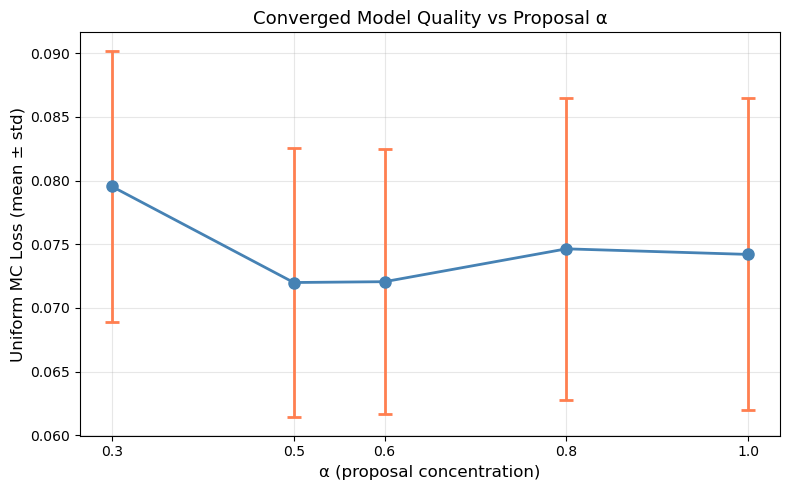

In [12]:
means = [mc_estimates[a].mean() for a in ALPHA_VALUES]
stds = [mc_estimates[a].std() for a in ALPHA_VALUES]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(ALPHA_VALUES, means, yerr=stds, fmt='o-', capsize=5, capthick=2,
            markersize=8, linewidth=2, color='steelblue', ecolor='coral', elinewidth=2)
ax.set_xlabel('α (proposal concentration)', fontsize=12)
ax.set_ylabel('Uniform MC Loss (mean ± std)', fontsize=12)
ax.set_title('Converged Model Quality vs Proposal α', fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_xticks(ALPHA_VALUES)
plt.tight_layout()
plt.show()

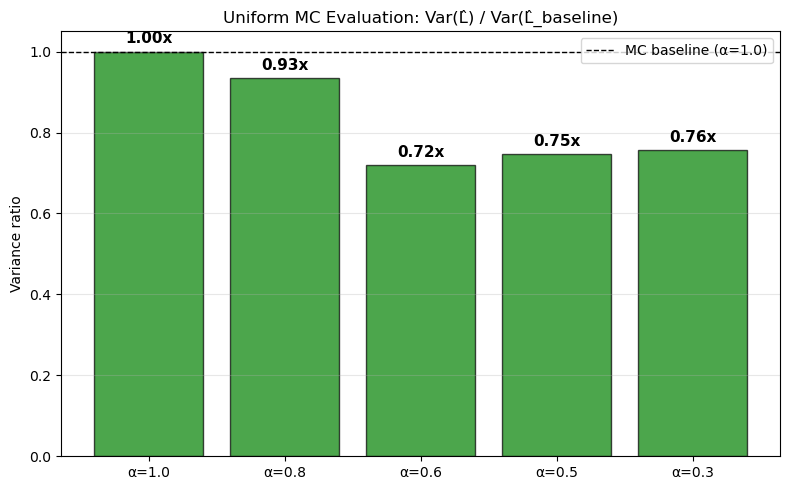

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(ALPHA_VALUES))
labels = [f'α={a}' for a in ALPHA_VALUES]

mc_var_base = mc_estimates[1.0].var()
mc_ratios = [mc_estimates[a].var() / mc_var_base for a in ALPHA_VALUES]
colors_mc = ['green' if r <= 1.0 else 'red' for r in mc_ratios]
bars = ax.bar(x_pos, mc_ratios, color=colors_mc, alpha=0.7, edgecolor='black')
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='MC baseline (α=1.0)')
for bar, r in zip(bars, mc_ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{r:.2f}x', ha='center', fontsize=11, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylabel('Variance ratio')
ax.set_title('Uniform MC Evaluation: Var(L̂) / Var(L̂_baseline)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()